In [27]:
import os
import nibabel as nib
import re

original_images_dir = "../../datasets/ADNI/t1_mpr"

original_images = [f for f in os.listdir(original_images_dir) 
                         if f.endswith('.nii.gz') or f.endswith('.nii')]
plots_path = "images_ADNI_Nyul"

In [15]:
def get_subject_and_date(nifti_img, filename: str = '') -> tuple[str, str]:
    """
    Get subject ID and scan date from a NIfTI file.
    
    Args:
        nifti_img: A NiBabel image object
        filename: Optional filename to extract information from
        
    Returns:
        tuple: (subject_id, scan_date) where either could be 'unknown' if not found
    """
    subject_id = 'unknown'
    scan_date = 'unknown'
    
    # Get header information
    header = nifti_img.header
    descrip = header.get('descrip', '').tobytes().decode('utf-8').lower()
    db_name = header.get('db_name', '').tobytes().decode('utf-8').lower()
    
    # Try to find subject ID
    subject_patterns = [
        r'(sub-\w+)',           # BIDS format
        r'(adni_\d+)',          # ADNI format
        r'(s\d{4})',            # ADNI S#### format
        r'(subject[-_]\w+)'     # General format
    ]
    
    # Look in both header fields and filename
    text_to_search = f"{descrip} {db_name} {filename}".lower()
    
    for pattern in subject_patterns:
        match = re.search(pattern, text_to_search)
        if match:
            subject_id = match.group(1)
            break
    
    # Try to find date
    date_patterns = [
        r'(\d{4}-\d{2}-\d{2})',  # YYYY-MM-DD
        r'(\d{8})',              # YYYYMMDD
        r'(\d{2}/\d{2}/\d{4})'   # MM/DD/YYYY
    ]
    
    for pattern in date_patterns:
        match = re.search(pattern, text_to_search)
        if match:
            scan_date = match.group(1)
            # Convert YYYYMMDD to YYYY-MM-DD if needed
            if len(scan_date) == 8 and scan_date.isdigit():
                scan_date = f"{scan_date[:4]}-{scan_date[4:6]}-{scan_date[6:]}"
            break
    
    return subject_id, scan_date

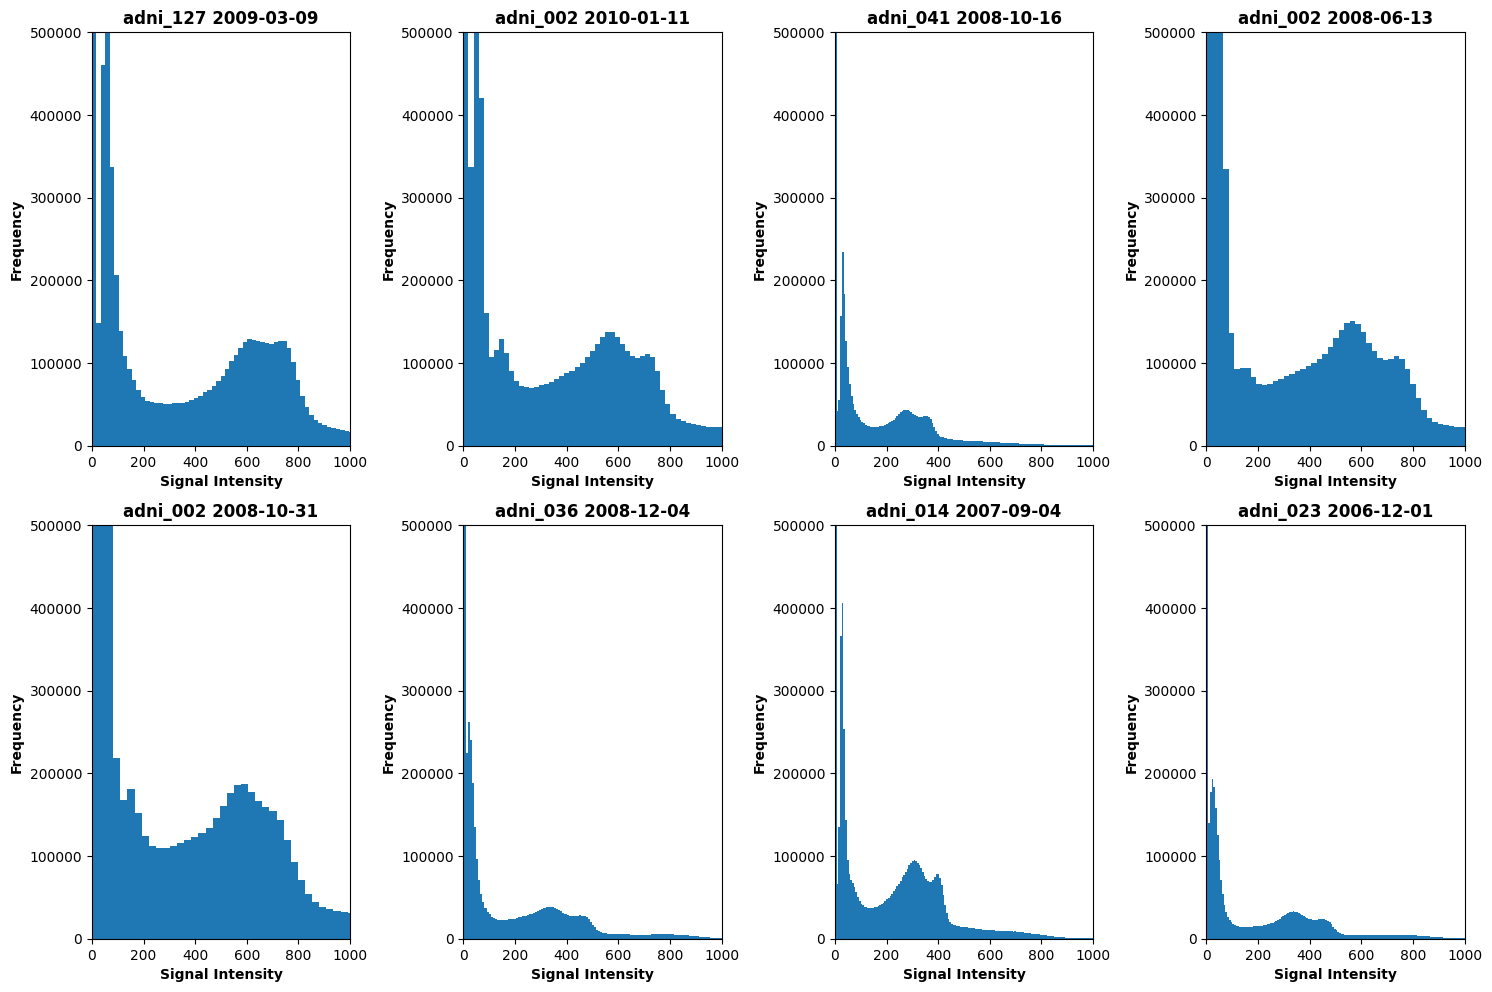

In [18]:
# draw histogram of the t1_scans before the harmonization
import matplotlib.pyplot as plt
from pathlib import Path
import random
num_bins = 200

filter_threshold = 100
num_cols = 4
fig, axs = plt.subplots(2, num_cols, figsize=(15, 10))
cnt = 0  
random_images = random.sample(original_images, 8)
for scan_file in random_images:
    image_file = os.path.join(original_images_dir, scan_file)

    img = nib.load(image_file).get_fdata()
    scan_date = "1" #scan_file.split('_')[0]
    subject_id, scan_date = get_subject_and_date(nib.load(image_file), scan_file)

    axs[cnt//num_cols, cnt%num_cols].hist(img.flatten(), bins=num_bins)
    axs[cnt//num_cols, cnt%num_cols].set_title(f"{subject_id} {scan_date}", fontsize=12, fontweight='bold')
    axs[cnt//num_cols, cnt%num_cols].set_xlabel('Signal Intensity', fontweight='bold')
    axs[cnt//num_cols, cnt%num_cols].set_ylabel('Frequency', fontweight='bold')
    axs[cnt//num_cols, cnt%num_cols].set_xlim(0, 1000)
    axs[cnt//num_cols, cnt%num_cols].set_ylim(0, 5e5)
    cnt += 1

plt.tight_layout(pad=1.0)
plt.savefig(f'{plots_path}/ADNI_original_intensity_distribution_Nyul.png')
plt.show()

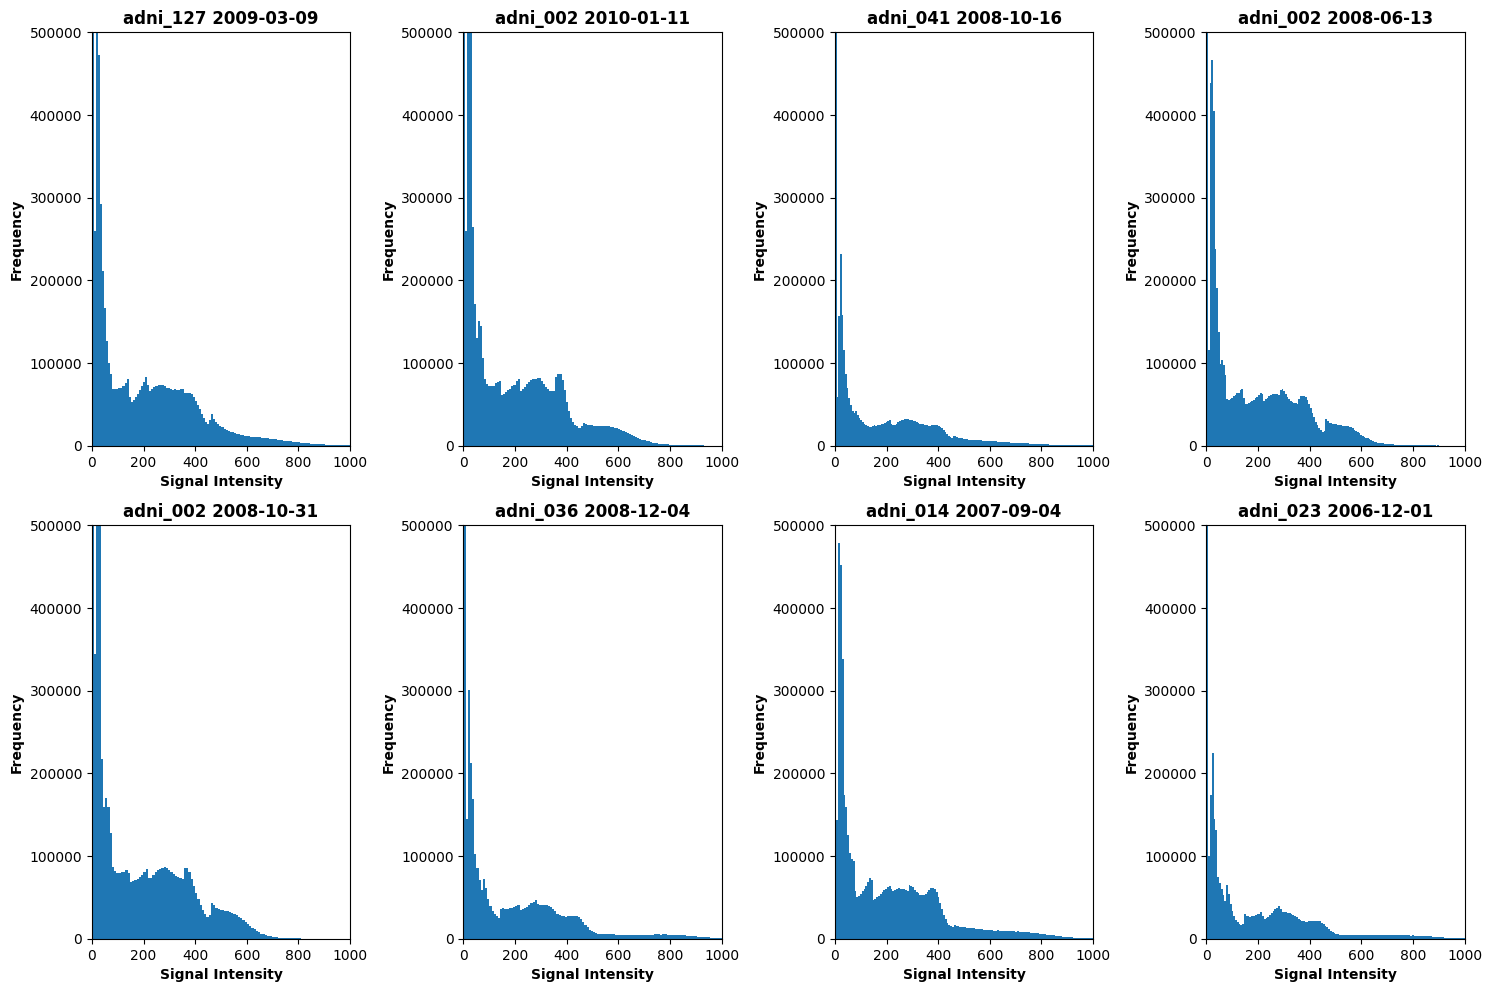

In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path
import random
num_bins = 200

filter_threshold = 100
num_cols = 4
fig, axs = plt.subplots(2, num_cols, figsize=(15, 10))
cnt = 0  
normalized_images_dir = "../../datasets/ADNI/t1_mpr_normalized"

for scan_file in random_images:
    image_file = os.path.join(normalized_images_dir, f"{Path(scan_file).stem.split('.')[0]}.nii.gz")

    img = nib.load(image_file).get_fdata()
    subject_id, scan_date = get_subject_and_date(nib.load(image_file), scan_file)

    axs[cnt//num_cols, cnt%num_cols].hist(img.flatten(), bins=num_bins)
    axs[cnt//num_cols, cnt%num_cols].set_title(f"{subject_id} {scan_date}", fontsize=12, fontweight='bold')
    axs[cnt//num_cols, cnt%num_cols].set_xlabel('Signal Intensity', fontweight='bold')
    axs[cnt//num_cols, cnt%num_cols].set_ylabel('Frequency', fontweight='bold')
    axs[cnt//num_cols, cnt%num_cols].set_xlim(0, 1000)
    axs[cnt//num_cols, cnt%num_cols].set_ylim(0, 5e5)
    cnt += 1

plt.tight_layout(pad=1.0)
plt.savefig(f'{plots_path}/ADNI_normalized_intensity_distribution_Nyul.png')
plt.show()

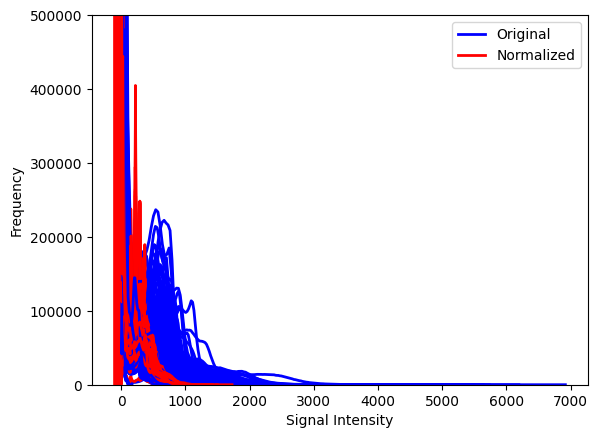

In [24]:
# draw histogram of the normalized images
import numpy as np
for idx, scan_file in enumerate(original_images):
    # plot the histogram of the original image
    original_image = nib.load(os.path.join(original_images_dir, scan_file)).get_fdata()
    hist_values, bin_edges = np.histogram(original_image, bins=num_bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    plt.plot(bin_centers, hist_values, '-', linewidth=2, color='blue',  label='Original' if idx == 0 else "")

    # plot the histogram of the normalized image
    normalized_image = nib.load(os.path.join(normalized_images_dir, f"{Path(scan_file).stem.split('.')[0]}.nii.gz")).get_fdata()
    hist_values, bin_edges = np.histogram(normalized_image, bins=num_bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    plt.plot(bin_centers, hist_values, '-', linewidth=2, color='red',  label='Normalized' if idx == 0 else "")

    
#plt.title(scan_dates[idx], fontsize=12, fontweight='bold')
# plt.xlim(0, 000)
plt.ylim(0, 5e5)
plt.xlabel('Signal Intensity')
plt.ylabel('Frequency')
plt.legend(loc='upper right')
plt.savefig(f'{plots_path}/ADNI_image_intensity_histogram_comparison.png')
plt.show()

(2,)


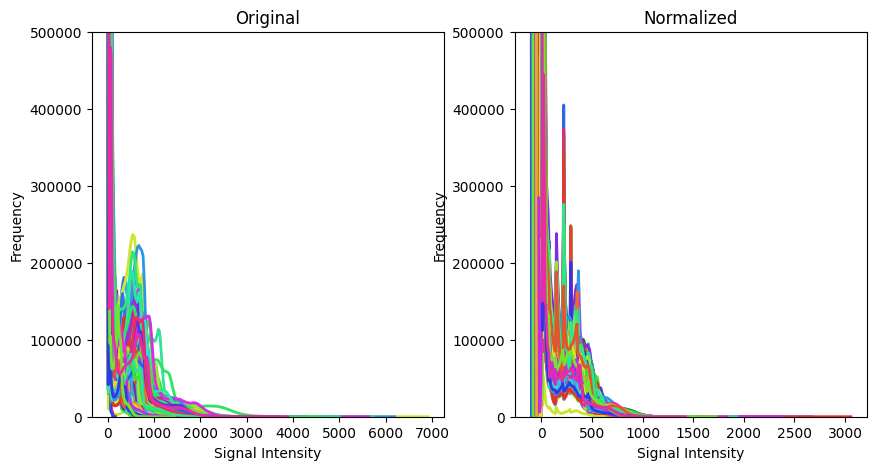

In [ ]:
"""Utility functions for visualizing and comparing feature histograms."""

import numpy as np
import matplotlib.pyplot as plt
from typing import Union, List, Tuple
import seaborn as sns
import colorsys

def generate_distinct_colors(n: int) -> list:
    """Generate n visually distinct colors.
    
    Args:
        n: Number of colors to generate
        
    Returns:
        List of colors in hex format
    """
    colors = []
    
    # Start with some hand-picked distinct colors
    base_colors = [
        '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',  # Default matplotlib
        '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf',
        '#ff0000', '#00ff00', '#0000ff', '#ffff00', '#ff00ff',  # Pure RGB and CMYK
        '#00ffff', '#800000', '#008000', '#000080', '#808000',
        '#800080', '#008080', '#ff8c00', '#8b4513', '#483d8b',  # Dark and medium tones
        '#2f4f4f', '#556b2f', '#a0522d', '#4b0082', '#708090',
    ]
    colors.extend(base_colors)
    
    # If we need more colors, generate them using HSV color space
    if n > len(colors):
        remaining = n - len(colors)
        for i in range(remaining):
            # Generate colors by varying hue while keeping saturation and value fixed
            hue = (i * 0.618033988749895) % 1  # Use golden ratio to space out hues
            saturation = 0.8  # High saturation for distinctiveness
            value = 0.9  # High value but not too bright
            
            # Convert HSV to RGB
            rgb = colorsys.hsv_to_rgb(hue, saturation, value)
            
            # Convert RGB to hex
            hex_color = '#{:02x}{:02x}{:02x}'.format(
                int(rgb[0] * 255),
                int(rgb[1] * 255),
                int(rgb[2] * 255)
            )
            colors.append(hex_color)
    
    return colors[:n]

# Generate 37 distinct colors
COLORS = generate_distinct_colors(len(original_images))

num_cols = 2
fig, axs = plt.subplots(1, num_cols, figsize=(10, 5))
print(axs.shape)
# draw histogram of the normalized images
for idx, scan_file in enumerate(original_images):
    # plot the histogram of the original image
    original_image = nib.load(os.path.join(original_images_dir, scan_file)).get_fdata()
    hist_values, bin_edges = np.histogram(original_image, bins=num_bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    axs[0].plot(bin_centers, hist_values, '-', linewidth=2, color=COLORS[idx])

    # plot the histogram of the normalized image
    normalized_image = nib.load(os.path.join(normalized_images_dir, f"{Path(scan_file).stem.split('.')[0]}.nii.gz")).get_fdata()
    hist_values, bin_edges = np.histogram(normalized_image, bins=num_bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    axs[1].plot(bin_centers, hist_values, '-', linewidth=2, color=COLORS[idx])

    
#plt.title(scan_dates[idx], fontsize=12, fontweight='bold')
# plt.xlim(0, 000)
axs[0].set_xlabel('Signal Intensity')
axs[0].set_ylabel('Frequency')
axs[0].set_title('Original')
axs[0].set_ylim(0, 5e5)

axs[1].set_xlabel('Signal Intensity')
axs[1].set_ylabel('Frequency')
axs[1].set_title('Normalized')
axs[1].set_ylim(0, 5e5)
plt.savefig(f'{plots_path}/ADNI_image_histogram_original_normalized.png')
plt.show()